In [1]:
.libPaths("~/R/x86_64-pc-linux-gnu-library/4.4/")

library(Seurat)
library(dplyr)
library(tidyverse)

Loading required package: SeuratObject

Loading required package: sp

‘SeuratObject’ was built with package ‘Matrix’ 1.7.4 but the current
version is 1.7.5; it is recomended that you reinstall ‘SeuratObject’ as
the ABI for ‘Matrix’ may have changed


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ ggplot2   4.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.4     ✔ tibble    3.3.0
✔ purrr     1.2.0     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://c

# Gut 5p CD3_NK

In [42]:
ls()

[1] "barcodes_cd4_ctl" "blood_3p_subset"  "gut_5p_all"       "gut_allt_3p"     
[5] "pallete_blood"

In [2]:
gut_5p_all  <- readRDS("../241201_VN_PREDICT2/data/cdn/gut_allt_5p_integrated.rds")

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



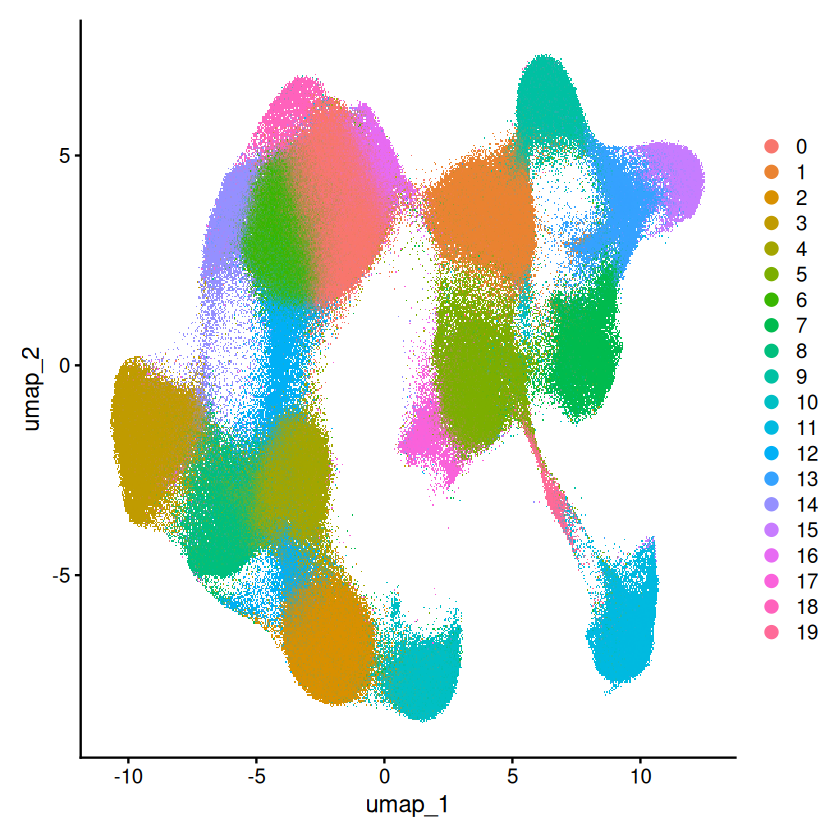

In [3]:
DimPlot(gut_5p_all)

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 588063
Number of edges: 13479680

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9525
Number of communities: 10
Elapsed time: 758 seconds


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



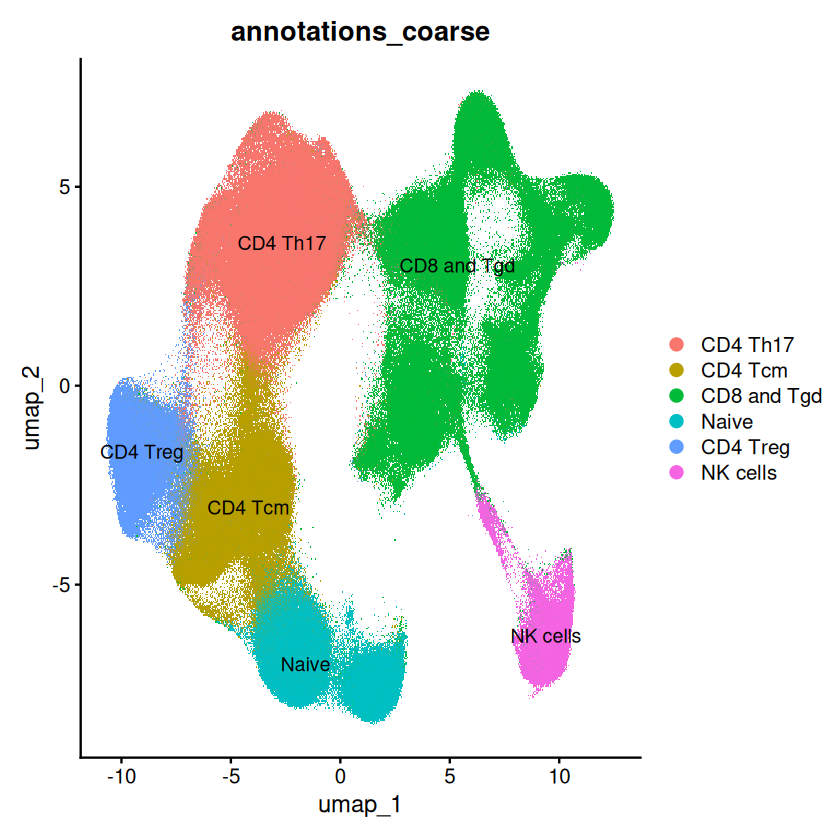

In [4]:
gut_5p_all  <- FindClusters(gut_5p_all, res = c(0.2))

gut_5p_all@meta.data <- gut_5p_all@meta.data  %>% mutate(annotations_coarse = recode_factor(integrated_snn_res.0.2, 
"0" = "CD4 Th17",                                                                         
"1" = "CD4 Tcm",
"2" = "CD8 and Tgd",
"3" = "Naive",
"4" = "CD4 Treg",
"5" = "CD8 and Tgd",
"6" = "CD8 and Tgd",
"7" = "CD8 and Tgd",
"8" = "NK cells",
"9" = "Naive"))

DimPlot(gut_5p_all, group.by = "annotations_coarse", label = T)

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



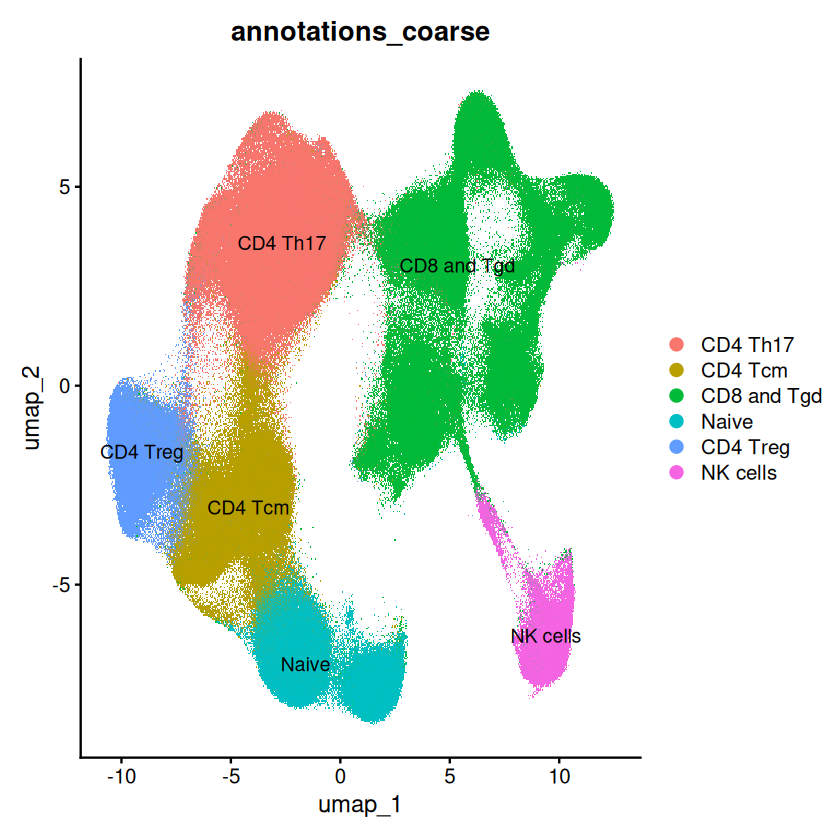

In [5]:
DimPlot(gut_5p_all, group.by = "annotations_coarse", label = T)

In [6]:
gut_5p_all@meta.data  <- gut_5p_all@meta.data  %>% dplyr::select(orig.ident, nCount_RNA, nFeature_RNA, 
                                                             seurat_clusters = integrated_snn_res.0.2,
                                                             participant_id, diagnosis, timepoint, age, sex, 
                                                             tissue, layer, antitnf_response)

In [ ]:
gut_5p_all@meta.data <- gut_5p_all@meta.data  %>% mutate(annotations = recode_factor(seurat_clusters, 
"0" = "CD4 Th17",                                                                         
"1" = "CD4 Tcm",
"2" = "CD8 and Tgd",
"3" = "Naive",
"4" = "CD4 Treg",
"5" = "CD8 and Tgd",
"6" = "CD8 and Tgd",
"7" = "CD8 and Tgd",
"8" = "NK cells",
"9" = "Naive"))

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



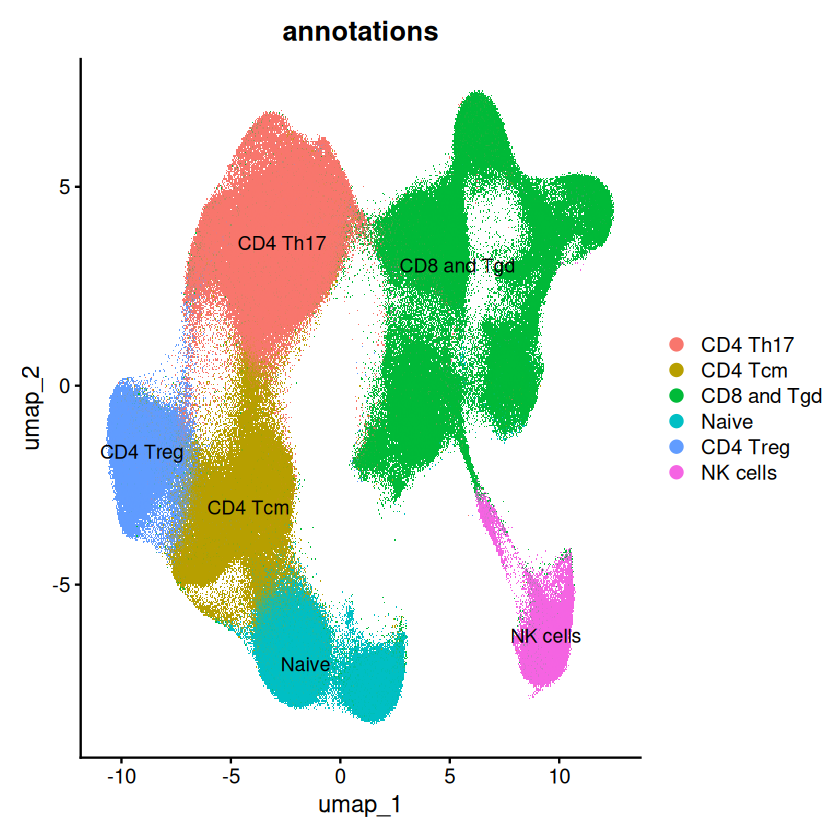

In [8]:
DimPlot(gut_5p_all, group.by = "annotations", label = T)

In [9]:
gut_5p_all@meta.data  %>% colnames

[1] "orig.ident"       "nCount_RNA"       "nFeature_RNA"     "seurat_clusters" 
 [5] "participant_id"   "diagnosis"        "timepoint"        "age"             
 [9] "sex"              "tissue"           "layer"            "antitnf_response"
[13] "annotations"

In [10]:
saveRDS(gut_5p_all, "data/SCP/Gut_CD3NK_5p.rds")

# Gut 3p CD3_NK

In [17]:
rm(gut_5p_all)

In [11]:
gut_allt_3p <- readRDS("../241201_VN_PREDICT2/gut_3p_integrated_with_healthy_filt_without_ilc_v2.rds")

In [12]:
pallete  <- c("Naive" = "#b288d9ff",
              "CD4 Tcm" = "#d9a988ff",
              "CD4 Th17" = "#b1d988ff",
              "CD4 Treg" = "#f0c963ff",
              "CD8 and Tgd" = "#88d9c4ff",
              "IEL" = "#88b8d9ff",
              "NK cells" = "#88b8d8ff")

In [13]:
gut_allt_3p@reductions$umap@cell.embeddings[,1]  <- -1*gut_allt_3p@reductions$umap@cell.embeddings[,1]

In [14]:
gut_allt_3p@reductions$umap@cell.embeddings[,2]  <- -1*gut_allt_3p@reductions$umap@cell.embeddings[,2]

In [15]:
gut_allt_3p@meta.data <- gut_allt_3p@meta.data  %>% mutate(annotations_coarse = 
                                                                       recode_factor(integrated_snn_res.0.3, 
"0" = "CD4 Th17",                                                                         
"1" = "Naive",
"2" = "CD8 and Tgd",
"3" = "CD4 Tcm",
"4" = "CD4 Treg",
"5" = "CD8 and Tgd",
"6" = "CD8 and Tgd",
"7" = "NK cells",
"8" = "CD4 Tcm",
"9" = "CD4 Th17",
"10" = "CD8 and Tgd"))

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



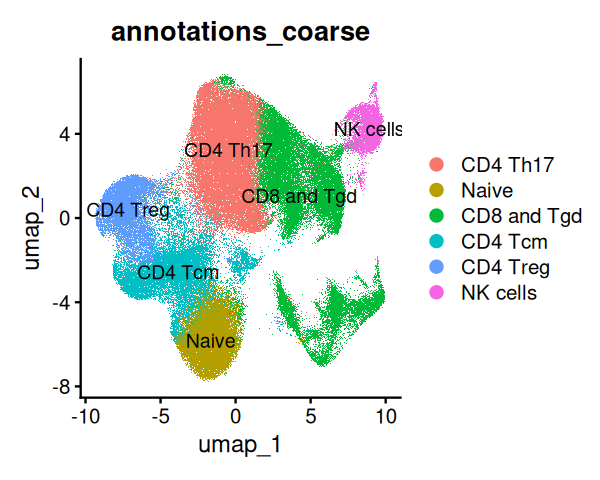

In [16]:
options(repr.plot.width = 5, repr.plot.height = 4)
DimPlot(gut_allt_3p, group.by = "annotations_coarse", label = T)

In [18]:
gut_allt_3p@meta.data  %>% colnames

[1] "SingleR_HPCA"           "nCount_RNA"             "nFeature_RNA"          
 [4] "RNA_snn_res.0.3"        "seurat_clusters"        "orig.ident"            
 [7] "smp_id"                 "percent.mt"             "patient"               
[10] "time"                   "tissue"                 "layer"                 
[13] "prime"                  "RNA_snn_res.0.2"        "RNA_snn_res.0.6"       
[16] "RNA_snn_res.0.7"        "RNA_snn_res.0.8"        "manual_annotation"     
[19] "smp_id2"                "disease"                "antiTNF_response"      
[22] "barcode"                "integrated_snn_res.0.3" "integrated_snn_res.0.5"
[25] "integrated_snn_res.0.7" "integrated_snn_res.0.9" "annotations_coarse"

In [19]:
gut_allt_3p@meta.data  <- gut_allt_3p@meta.data  %>% dplyr::select(orig.ident = smp_id, nCount_RNA, nFeature_RNA, 
                                                             seurat_clusters = integrated_snn_res.0.3,
                                                             participant_id = patient, diagnosis = disease, 
                                                                           timepoint = time, 
                                                             tissue, layer, antitnf_response = antiTNF_response, 
                                                                           annotations = annotations_coarse)

In [20]:
gut_allt_3p@meta.data  %>% colnames()

[1] "orig.ident"       "nCount_RNA"       "nFeature_RNA"     "seurat_clusters" 
 [5] "participant_id"   "diagnosis"        "timepoint"        "tissue"          
 [9] "layer"            "antitnf_response" "annotations"

In [21]:
saveRDS(gut_allt_3p, "data/SCP/Gut_CD3NK_3p.rds")

In [22]:
rm(gut_allt_3p)

In [23]:
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,4325613,231.1,13549060,723.6,13549060,723.6
Vcells,1374277448,10485.0,7512966268,57319.4,7166623310,54677.0


In [36]:
gut_allt_3p  <- readRDS("data/SCP/Gut_CD3NK_3p.rds")

# Gut 5p CD4

In [25]:
gut_cdn <- readRDS("../241201_VN_PREDICT2/data/cdn/gut_5p_integrated_cd4_prolif_filt.rds")

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



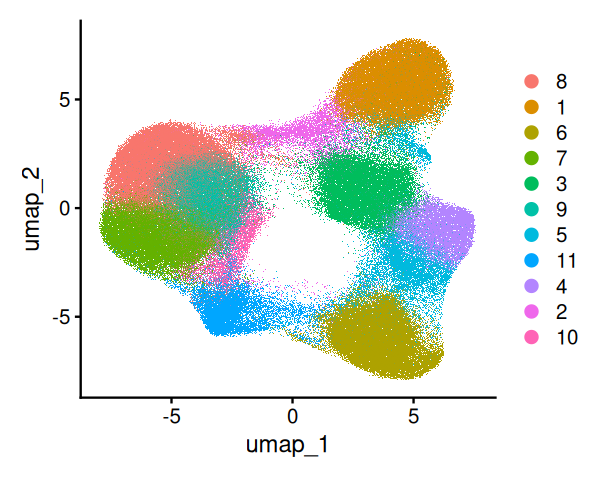

In [27]:
DimPlot(gut_cdn)

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



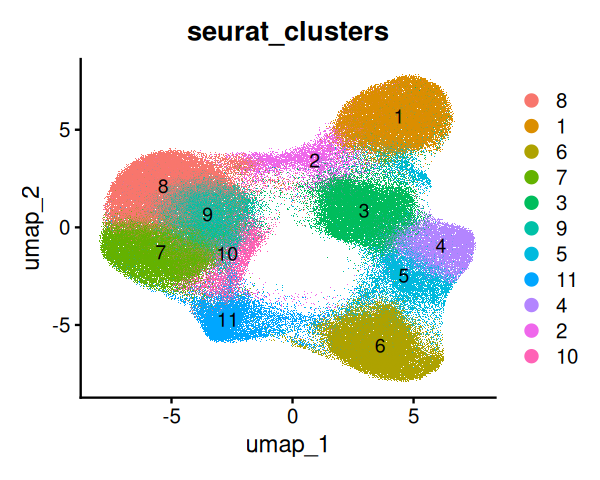

In [54]:
DimPlot(gut_cdn, group.by = "seurat_clusters", label = T)

In [53]:
colnames(gut_cdn@meta.data)

[1] "orig.ident"                  "nCount_RNA"                 
  [3] "nFeature_RNA"                "bc"                         
  [5] "data_folder"                 "data_folder2"               
  [7] "sample"                      "diagnosis"                  
  [9] "subgroup_primary"            "subgroup_secondary"         
 [11] "subgroup_tertiary"           "Rome_coarse"                
 [13] "Rome_classification"         "antitnf_response"           
 [15] "participant_id"              "timepoint"                  
 [17] "age"                         "sex"                        
 [19] "site"                        "tissue"                     
 [21] "layer"                       "prime"                      
 [23] "version_10x"                 "sample_old"                 
 [25] "data_type"                   "seq_run"                    
 [27] "collection_purpose"          "collection_date"            
 [29] "days"                        "antitnf"                    
 [31] "antitnf_repeat"              "duo_inflammation"           
 [33] "ile_inflammation"            "col_inflammation"           
 [35] "sample_inflamed"             "colon_site"                 
 [37] "score_type"                  "severity_score"             
 [39] "weighted_severity_score"     "severity_score_date"        
 [41] "severity_score_range"        "weighted_score_range"       
 [43] "barcodes"                    "scrublet_doublet_scores"    
 [45] "outliers"                    "n_outliers"                 
 [47] "n_genes_by_counts"           "log1p_n_genes_by_counts"    
 [49] "total_counts"                "log1p_total_counts"         
 [51] "pct_counts_in_top_50_genes"  "pct_counts_in_top_100_genes"
 [53] "pct_counts_in_top_200_genes" "pct_counts_in_top_500_genes"
 [55] "total_counts_mt"             "log1p_total_counts_mt"      
 [57] "pct_counts_mt"               "total_counts_ribo"          
 [59] "log1p_total_counts_ribo"     "pct_counts_ribo"            
 [61] "total_counts_hb"             "log1p_total_counts_hb"      
 [63] "pct_counts_hb"               "quality_label"              
 [65] "predicted_labels"            "celltypist_score"           
 [67] "lvl1_annot"                  "quality_label1"             
 [69] "quality_label2"              "quality_label3"             
 [71] "lvl2_annot"                  "leiden_0.05"                
 [73] "leiden_0.1"                  "leiden_0.125"               
 [75] "leiden_0.15"                 "leiden_0.175"               
 [77] "leiden_0.2"                  "leiden_0.225"               
 [79] "leiden_0.25"                 "leiden_0.3"                 
 [81] "lvl3_annot_types"            "lvl3_annot_states"          
 [83] "RNA_snn_res.0.3"             "seurat_clusters"            
 [85] "barcode"                     "integrated_snn_res.0.5"     
 [87] "nCount_RNA3"                 "nFeature_RNA3"              
 [89] "leiden_0.3_mod"              "integrated_snn_res.0.6"     
 [91] "integrated_snn_res.0.7"      "integrated_snn_res.0.8"     
 [93] "cluster_and_sample"          "Singler_Th17"               
 [95] "age_group"                   "is_cell"                    
 [97] "chain"                       "contig_id"                  
 [99] "high_confidence"             "productive"                 
[101] "length"                      "reads"                      
[103] "umis"                        "vdj_source"                 
[105] "count_TRA"                   "count_TRB"                  
[107] "count_Multi"                 "cdr3_A1"                    
[109] "cdr3_A1_nt"                  "cdr3_A2"                    
[111] "cdr3_A2_nt"                  "cdr3_B"                     
[113] "cdr3_B_nt"                   "cdr3_Multi"                 
[115] "cdr3_Multi_nt"               "v_gene_A1"                  
[117] "j_gene_A1"                   "v_gene_A2"                  
[119] "j_gene_A2"                   "v_gene_B"                   
[121] "d_gene_B"                    "j_gen

In [55]:
gut_cdn@meta.data <- gut_cdn@meta.data %>% dplyr::select(orig.ident, nCount_RNA, nFeature_RNA, 
                                                             seurat_clusters,
                                                             participant_id, diagnosis, timepoint, age, sex, 
                                                             tissue, layer, antitnf_response)

In [56]:
gut_cdn@meta.data  %>% colnames()

[1] "orig.ident"       "nCount_RNA"       "nFeature_RNA"     "seurat_clusters" 
 [5] "participant_id"   "diagnosis"        "timepoint"        "age"             
 [9] "sex"              "tissue"           "layer"            "antitnf_response"

In [57]:
object.size(gut_cdn)
object.size(gut_cdn[["RNA"]]@counts)
object.size(gut_cdn[["RNA"]]@data)
object.size(gut_cdn[["RNA"]]@scale.data)

38696453800 bytes

5938576848 bytes

5938576848 bytes

216 bytes

In [58]:
saveRDS(gut_cdn, "data/SCP/Gut_CD4_5p.rds")

In [59]:
rm(list = ls())

# Gut 3p CD4

In [26]:
gut_cd4_3p  <- readRDS("../241201_VN_PREDICT2/gut_3p_integrated_filt_without_ilc_v4_just_cd4.rds")

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



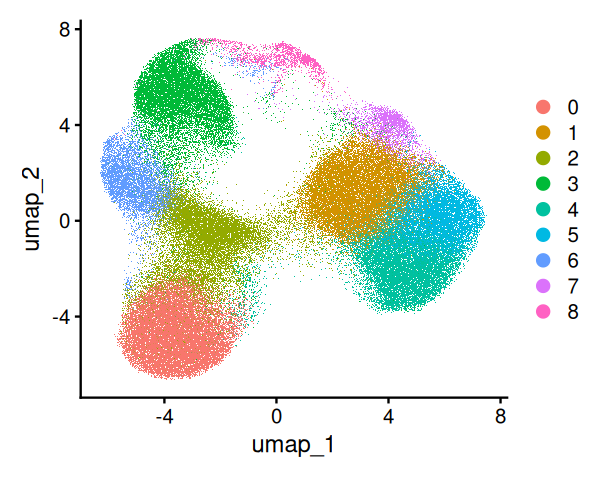

In [28]:
DimPlot(gut_cd4_3p)

In [29]:
gut_cd4_3p@reductions$umap@cell.embeddings[,1]  <- -1*gut_cd4_3p@reductions$umap@cell.embeddings[,1]
gut_cd4_3p@reductions$umap@cell.embeddings[,2]  <- -1*gut_cd4_3p@reductions$umap@cell.embeddings[,2]

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



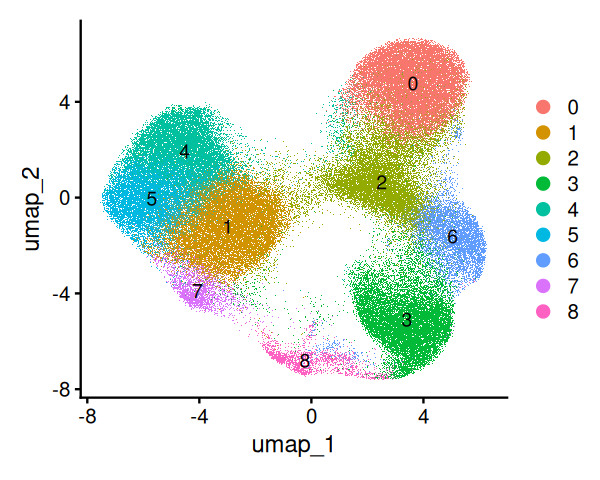

In [31]:
DimPlot(gut_cd4_3p, label = T)

In [32]:
colnames(gut_cd4_3p@meta.data)

[1] "SingleR_HPCA"           "nCount_RNA"             "nFeature_RNA"          
 [4] "patient"                "time"                   "tissue"                
 [7] "layer"                  "prime"                  "RNA_snn_res.0.3"       
[10] "seurat_clusters"        "orig.ident"             "smp_id"                
[13] "percent.mt"             "smp_id2"                "smp_id3"               
[16] "n"                      "data_folder"            "barcode"               
[19] "integrated_snn_res.0.5" "cd4"                    "cd8a"                  
[22] "cd8b"                   "cd4_or_cd8"             "cd4_or_cd8_2"          
[25] "integrated_snn_res.0.6" "integrated_snn_res.0.7" "integrated_snn_res.0.8"
[28] "integrated_snn_res.0.9" "integrated_snn_res.1"   "annotations"           
[31] "cluster_sample"         "cd8"

In [33]:
gut_cd4_3p$seurat_clusters_orig  <- gut_cd4_3p$seurat_clusters
gut_cd4_3p@meta.data <- gut_cd4_3p@meta.data %>% mutate(seurat_clusters = recode_factor(seurat_clusters_orig, 
                                                                              "0" = '1',
                                                                               "1" = "7",
                                                                               "2" = "2",
                                                                               "3" = "4",
                                                                               "4" = "5",
                                                                               "5" = "6",
                                                                               "6" = "3",
                                                                               "7" = "8",
                                                                               "8" = "9"))

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



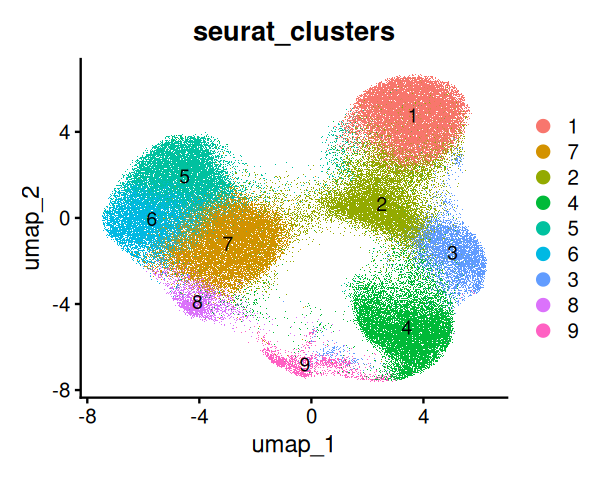

In [34]:
DimPlot(gut_cd4_3p, label = T, group.by = "seurat_clusters")

In [35]:
colnames(gut_cd4_3p@meta.data)

[1] "SingleR_HPCA"           "nCount_RNA"             "nFeature_RNA"          
 [4] "patient"                "time"                   "tissue"                
 [7] "layer"                  "prime"                  "RNA_snn_res.0.3"       
[10] "seurat_clusters"        "orig.ident"             "smp_id"                
[13] "percent.mt"             "smp_id2"                "smp_id3"               
[16] "n"                      "data_folder"            "barcode"               
[19] "integrated_snn_res.0.5" "cd4"                    "cd8a"                  
[22] "cd8b"                   "cd4_or_cd8"             "cd4_or_cd8_2"          
[25] "integrated_snn_res.0.6" "integrated_snn_res.0.7" "integrated_snn_res.0.8"
[28] "integrated_snn_res.0.9" "integrated_snn_res.1"   "annotations"           
[31] "cluster_sample"         "cd8"                    "seurat_clusters_orig"

In [38]:
patient_disease_response_map  <- gut_allt_3p@meta.data  %>% group_by(participant_id, diagnosis, 
                                                                     antitnf_response)  %>% tally()  %>% 
dplyr::select(-n)

In [39]:
patient_disease_response_map

participant_id,diagnosis,antitnf_response
<chr>,<chr>,<chr>
HE-001-014,HEA,NM
HE-001-023,HEA,NM
HE-001-024,HEA,NM
HE-001-025,HEA,NM
HE-001-026,HEA,NM
p002,FGID,NM
p003,FGID,NM
p009,FGID,NM
p010,CD,PR


In [42]:
gut_cd4_3p$patient %in% patient_disease_response_map$participant_id  %>% table

.
  TRUE 
166659 

In [43]:
new_md  <- gut_cd4_3p@meta.data  %>% mutate(participant_id = patient)  %>% 
left_join(patient_disease_response_map)

Joining with `by = join_by(participant_id)`


In [45]:
rownames(new_md)  <- colnames(gut_cd4_3p)

In [48]:
gut_cd4_3p@meta.data  <- new_md

In [49]:
gut_cd4_3p@meta.data  <- gut_cd4_3p@meta.data  %>% dplyr::select(orig.ident = smp_id, nCount_RNA, nFeature_RNA, 
                                                             seurat_clusters,
                                                             participant_id , diagnosis , 
                                                                           timepoint = time, 
                                                             tissue, layer, antitnf_response)

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



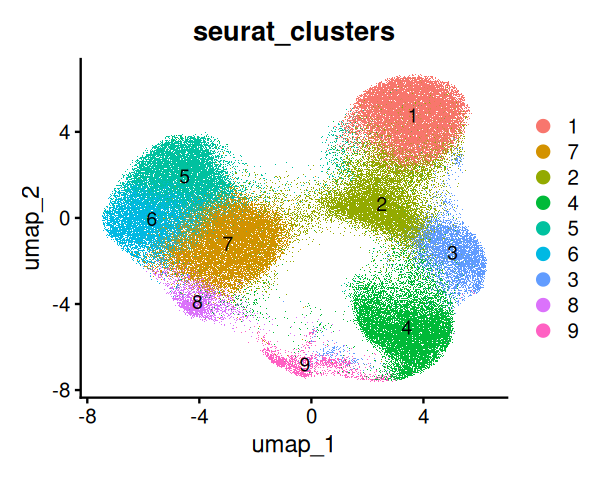

In [50]:
DimPlot(gut_cd4_3p, label = T, group.by = "seurat_clusters")

In [51]:
saveRDS(gut_cd4_3p, "data/SCP/Gut_CD4_3p.rds")

# Blood 5p CD3_NK

In [25]:
blood_5p  <- readRDS("../241201_VN_PREDICT2/data/5p_blood_2024/blood_5p_integrated_stacas_participant_filt_with_annot.rds")

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



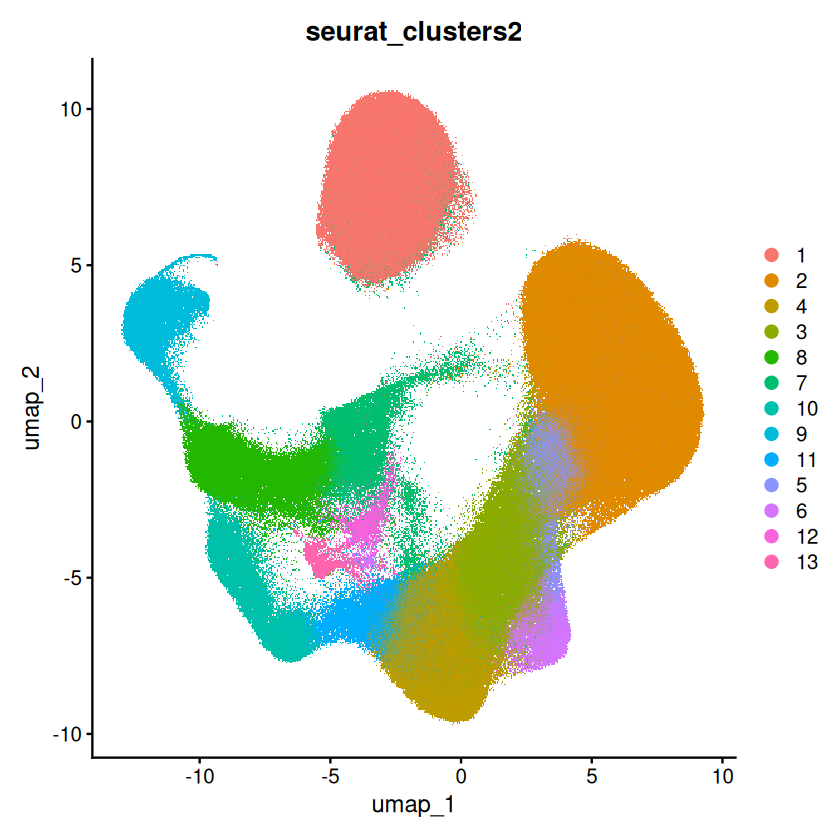

In [27]:
DimPlot(blood_5p, group.by = "seurat_clusters2")

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



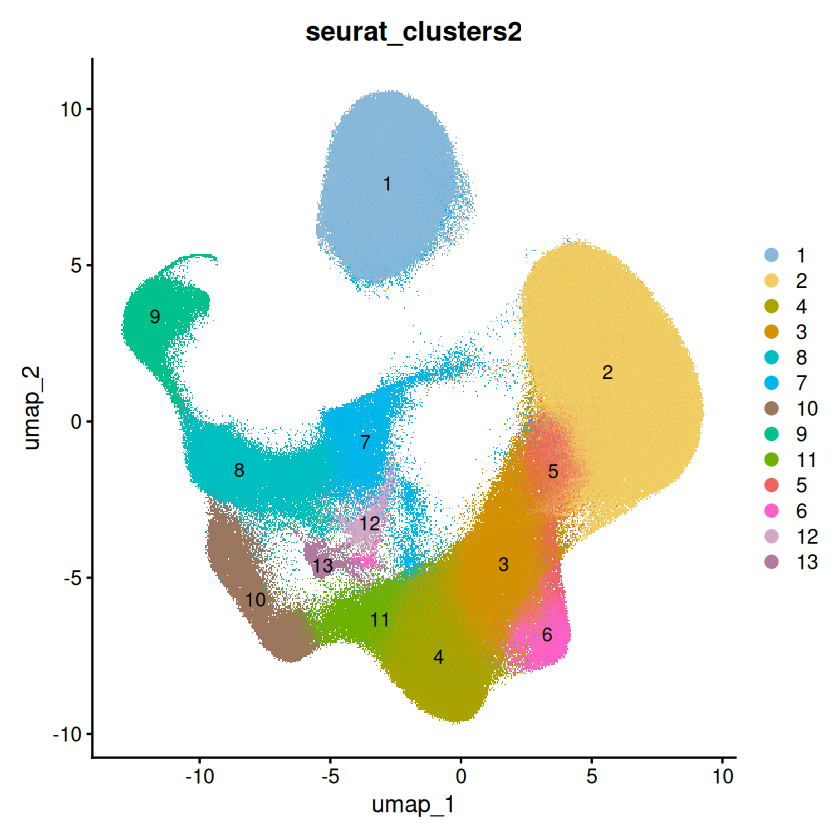

In [28]:
pallete_blood  <- c(
"1" =  "#89b8da",
"2" =  "#F1CE63",
"3" =  '#D39200',
"4" =  '#AAA300',
"5" =  'indianred2',
"6" =  '#FF61C9',
"7" =  '#00B6EB',
"8" =  '#00BFC2',
"9" =  '#00C08C',
"10" =  "#9D7660" ,
"11" =  '#6DB100',
"12" =  '#D4A6C8',
"13" =  '#B07AA1'
)

DimPlot(blood_5p, label = T, group.by = "seurat_clusters2", cols = pallete_blood)

In [29]:
blood_5p@meta.data  %>% colnames

[1] "orig.ident"              "nCount_RNA"             
 [3] "nFeature_RNA"            "percent.mt"             
 [5] "percent.rt"              "SingleR_HPCA"           
 [7] "data_folder"             "RNA_snn_res.0.3"        
 [9] "seurat_clusters"         "barcode"                
[11] "integrated_snn_res.0.4"  "sample"                 
[13] "diagnosis"               "subgroup_primary"       
[15] "subgroup_secondary"      "subgroup_tertiary"      
[17] "Rome_coarse"             "Rome_classification"    
[19] "antitnf_response"        "participant_id"         
[21] "timepoint"               "age"                    
[23] "sex"                     "site"                   
[25] "tissue"                  "layer"                  
[27] "prime"                   "version_10x"            
[29] "sample_old"              "data_type"              
[31] "seq_run"                 "collection_purpose"     
[33] "collection_date"         "days"                   
[35] "antitnf"                 "antitnf_repeat"         
[37] "duo_inflammation"        "ile_inflammation"       
[39] "col_inflammation"        "sample_inflamed"        
[41] "colon_site"              "score_type"             
[43] "severity_score"          "weighted_severity_score"
[45] "severity_score_date"     "severity_score_range"   
[47] "weighted_score_range"    "internal_flag"          
[49] "integrated_snn_res.0.6"  "integrated_snn_res.0.7" 
[51] "cluster_subclust1"       "annot_subclust"         
[53] "seurat_clusters2"        "annotations"            
[55] "subclust_vsm_res05"      "cd4_ctl"

In [33]:
blood_5p$cd4_ctl  %>% table

.
 FALSE   TRUE 
591958   1616 

In [34]:
blood_5p@meta.data  <- blood_5p@meta.data  %>% dplyr::select(orig.ident, nCount_RNA, nFeature_RNA, 
                                                             seurat_clusters = seurat_clusters2,
                                                             participant_id, diagnosis, timepoint, age, sex, 
                                                             tissue, layer, antitnf_response, cd4_ctl)

In [46]:
blood_5p[["RNA"]]@scale.data  <- NULL

<0 x 0 matrix>

In [45]:
object.size(blood_5p)
object.size(blood_5p[["RNA"]]@counts)
object.size(blood_5p[["RNA"]]@data)
object.size(blood_5p[["RNA"]]@scale.data)

36590160568 bytes

11329823544 bytes

11329823544 bytes

216 bytes

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



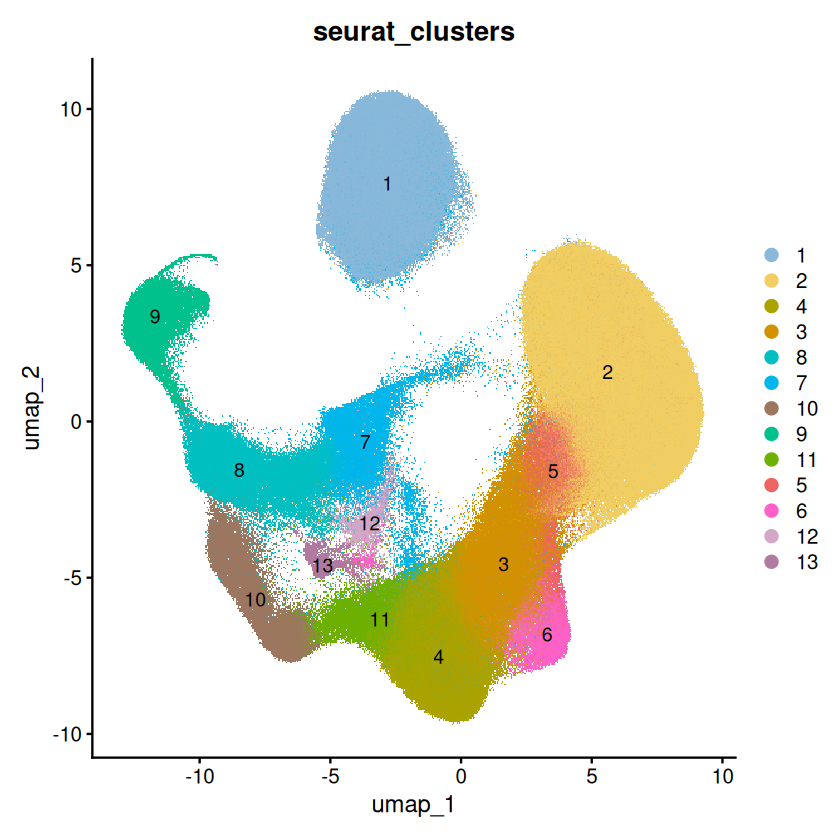

In [48]:
DimPlot(blood_5p, label = T, group.by = "seurat_clusters", cols = pallete_blood)

In [49]:
saveRDS(blood_5p, "data/SCP/Blood_CD3NK_5p.rds")

In [57]:
rm(blood_5p)
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,4457420,238.1,8099975,432.6,8099975,432.6
Vcells,1706861154,13022.4,7429756044,56684.6,6581155292,50210.3


# Blood 3p CD3_NK

In [2]:
blood_3p_stacas  <- readRDS("../241201_VN_PREDICT2/data/3p_blood_2021/blood_3p_integrated_stacas_sample.rds")

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



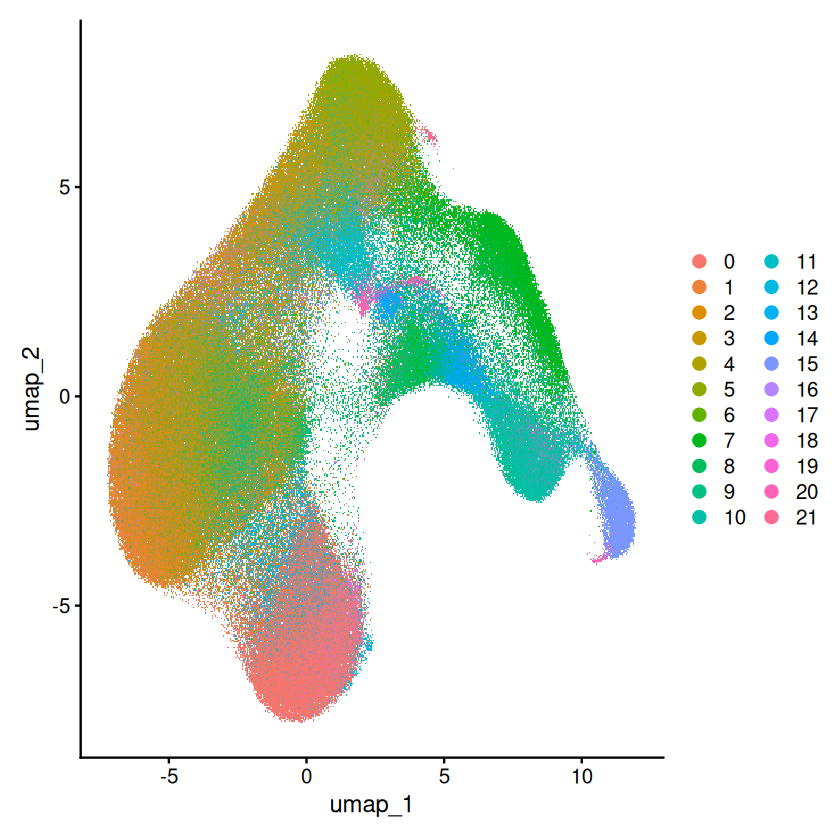

In [3]:
DimPlot(blood_3p_stacas)

In [4]:
DefaultAssay(blood_3p_stacas)

[1] "integrated"

In [5]:
blood_3p_stacas  <- FindNeighbors(blood_3p_stacas)
blood_3p_stacas  <- FindClusters(blood_3p_stacas, res = c(1.2))

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 324539
Number of edges: 7099228

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8253
Number of communities: 21
Elapsed time: 244 seconds


In [6]:
blood_3p_stacas@meta.data <- blood_3p_stacas@meta.data  %>% mutate(seurat_clusters2 = recode_factor(integrated_snn_res.1.2, 
                                                                              "0" = '2',
                                                                               "1" = '2',
                                                                               "2" = '4',
                                                                               "3" = '1',
                                                                               "4" = '3',
                                                                               "5" = '2',
                                                                               "6" = '2',
                                                                               "7" = '2',
                                                                               "8" = '1',
                                                                               "9" = '8',
                                                                               "10" = '10',
                                                                               "11" = '7',
                                                                               "12" = '5',
                                                                               "13" = '1',
                                                                               "14" = '11',
                                                                               "15" = '6',
                                                                               "16" = '7',
                                                                               "17" = '9',
                                                                               "18" = '13',
                                                                               "19" = '12',
                                                                               "20" = '4'
                                                                                     ))

In [10]:
blood_3p_stacas@reductions$umap@cell.embeddings[,1]  <- -1*blood_3p_stacas@reductions$umap@cell.embeddings[,1]
blood_3p_stacas@reductions$umap@cell.embeddings[,2]  <- -1*blood_3p_stacas@reductions$umap@cell.embeddings[,2]


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



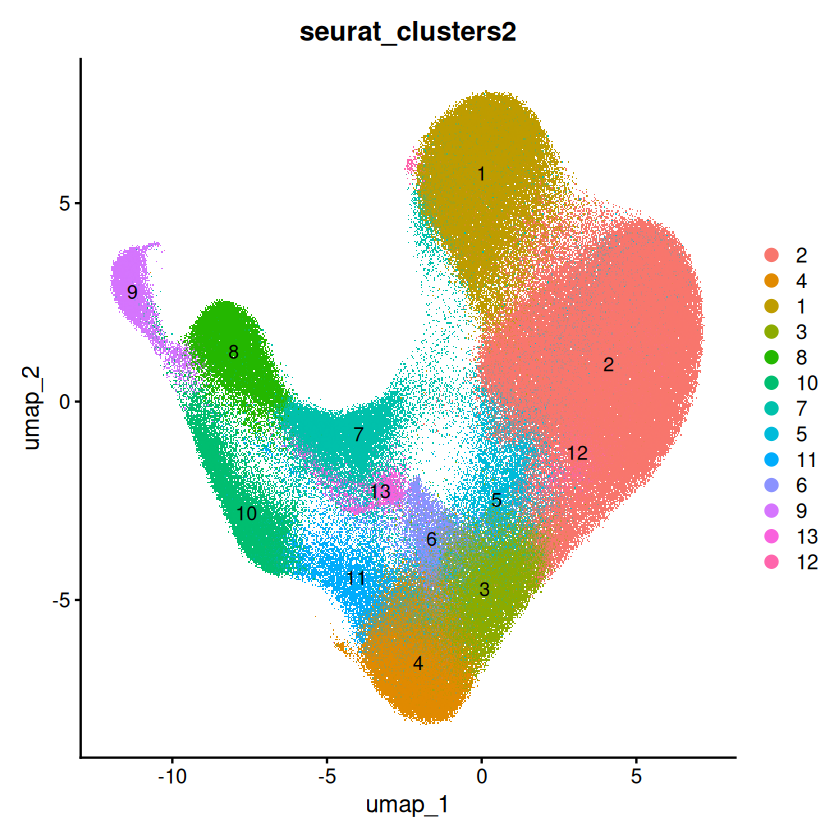

In [12]:
DimPlot(blood_3p_stacas, group.by = "seurat_clusters2", label = T)

In [14]:
blood_3p_stacas@meta.data  %>% colnames

[1] "SingleR_HPCA"           "nCount_RNA"             "nFeature_RNA"          
 [4] "patient"                "time"                   "tissue"                
 [7] "layer"                  "prime"                  "RNA_snn_res.0.3"       
[10] "seurat_clusters"        "barcode"                "disease"               
[13] "antiTNF_response"       "percent.mt"             "percent.rp"            
[16] "RNA_snn_res.0.8"        "manual_annots"          "RNA_snn_res.1"         
[19] "smp_id"                 "integrated_snn_res.1.2" "seurat_clusters2"

In [16]:
blood_3p_subset  <- readRDS("../241201_VN_PREDICT2/data/3p_blood_2021/vn_Tcells_3p_5p_datasets_blood_3p_subset.rds")

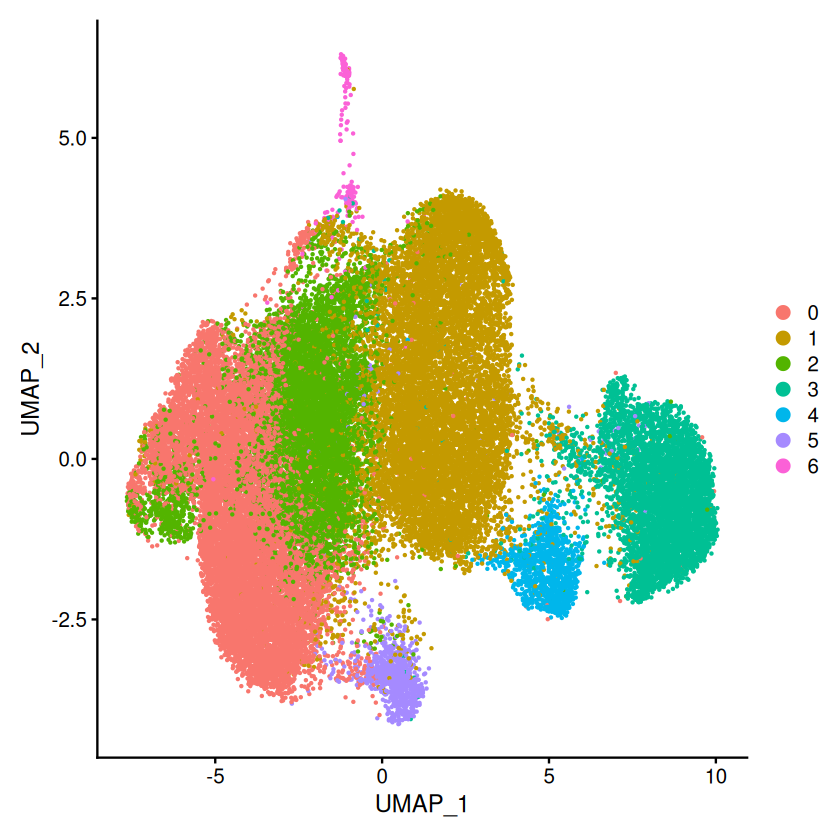

In [18]:
DimPlot(blood_3p_subset)

In [19]:
blood_3p_subset$seurat_clusters  %>% table

.
    0     1     2     3     4     5     6 
12625 11792  7705  5382  1151   926   251 

In [20]:
table(colnames(blood_3p_subset) %in% colnames(blood_3p_stacas))


 TRUE 
39832 

In [21]:
barcodes_cd4_ctl  <- colnames(subset(blood_3p_subset, seurat_clusters == 5))

In [23]:
barcodes_cd4_ctl  %>% length()

[1] 926

In [24]:
blood_3p_stacas$cd4_ctl  <- colnames(blood_3p_stacas) %in% barcodes_cd4_ctl

In [25]:
blood_3p_stacas$cd4_ctl  %>% table

.
 FALSE   TRUE 
323613    926 

In [26]:
blood_3p_stacas@meta.data  %>% colnames

[1] "SingleR_HPCA"           "nCount_RNA"             "nFeature_RNA"          
 [4] "patient"                "time"                   "tissue"                
 [7] "layer"                  "prime"                  "RNA_snn_res.0.3"       
[10] "seurat_clusters"        "barcode"                "disease"               
[13] "antiTNF_response"       "percent.mt"             "percent.rp"            
[16] "RNA_snn_res.0.8"        "manual_annots"          "RNA_snn_res.1"         
[19] "smp_id"                 "integrated_snn_res.1.2" "seurat_clusters2"      
[22] "cd4_ctl"

In [27]:
blood_3p_stacas@meta.data  <- blood_3p_stacas@meta.data  %>% dplyr::select(orig.ident = smp_id, nCount_RNA, nFeature_RNA, 
                                                             seurat_clusters = seurat_clusters2,
                                                             participant_id = patient, diagnosis = disease, 
                                                                           timepoint = time, 
                                                             tissue, layer, antitnf_response = antiTNF_response, 
                                                                           cd4_ctl)

In [29]:
object.size(blood_3p_stacas)
object.size(blood_3p_stacas[["RNA"]]@counts)
object.size(blood_3p_stacas[["RNA"]]@data)
object.size(blood_3p_stacas[["RNA"]]@scale.data)

13974279768 bytes

3279903872 bytes

3279903872 bytes

216 bytes

In [31]:
pallete_blood  <- c(
"1" =  "#89b8da",
"2" =  "#F1CE63",
"3" =  '#D39200',
"4" =  '#AAA300',
"5" =  'indianred2',
"6" =  '#FF61C9',
"7" =  '#00B6EB',
"8" =  '#00BFC2',
"9" =  '#00C08C',
"10" =  "#9D7660" ,
"11" =  '#6DB100',
"12" =  '#D4A6C8',
"13" =  '#B07AA1'
)


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



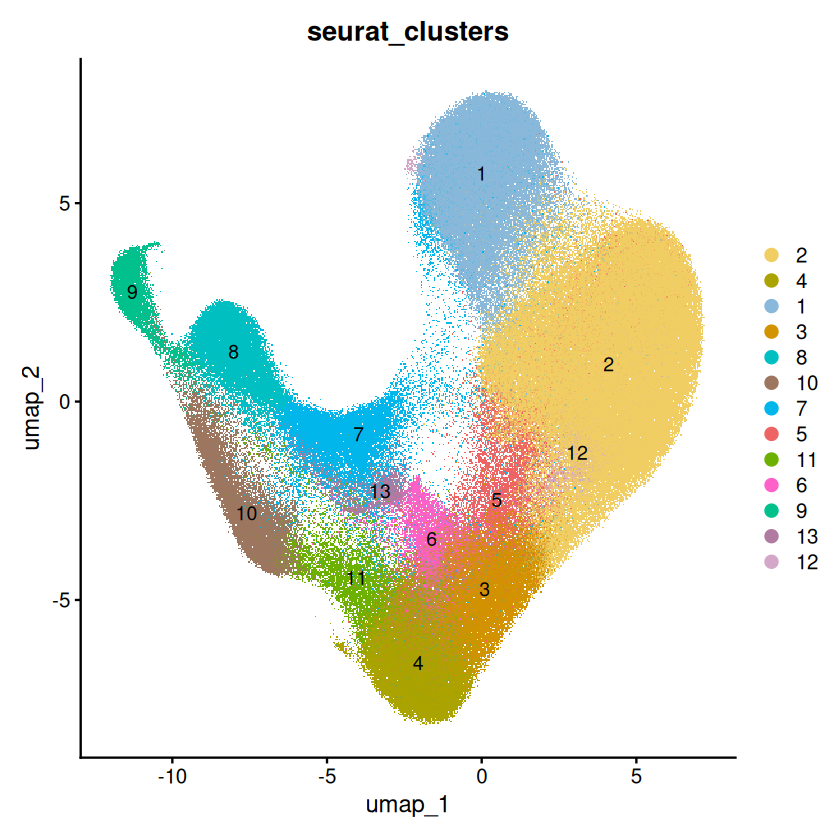

In [32]:
DimPlot(blood_3p_stacas, label = T, group.by = "seurat_clusters", cols = pallete_blood)

In [34]:
blood_3p_stacas@meta.data  %>% colnames

[1] "orig.ident"       "nCount_RNA"       "nFeature_RNA"     "seurat_clusters" 
 [5] "participant_id"   "diagnosis"        "timepoint"        "tissue"          
 [9] "layer"            "antitnf_response" "cd4_ctl"

In [35]:
saveRDS(blood_3p_stacas, "data/SCP/Blood_CD3NK_3p.rds")

In [36]:
rm(blood_3p_stacas)
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,4477479,239.2,9988340,533.5,9988340,533.5
Vcells,1862594075,14210.5,2793402431,21312.0,2066777908,15768.3


# Blood Sorted_CD4_CTL

In [2]:
cd4_ctl_sort  <- readRDS("../241201_VN_PREDICT2/data/sorted_cd4_ctl/merged.rds")

In [3]:
colnames(cd4_ctl_sort@meta.data)

[1] "orig.ident"         "nCount_RNA"         "nFeature_RNA"      
 [4] "RNA_snn_res.0.9"    "seurat_clusters"    "RNA_snn_res.0.5"   
 [7] "barcode"            "Freemuxlet_ID"      "Freemuxlet_doublet"
[10] "sample"

In [6]:
cd4_ctl_sort$sample  %>% table

.
Sample1 Sample2 
   2054     469 

In [7]:
cd4_ctl_sort$Sort_sample  <- ifelse(cd4_ctl_sort$sample == "Sample1", "CD4_control", "CD4_CTL")

In [8]:
cd4_ctl_sort$Sort_sample  %>% table

.
CD4_control     CD4_CTL 
       2054         469 

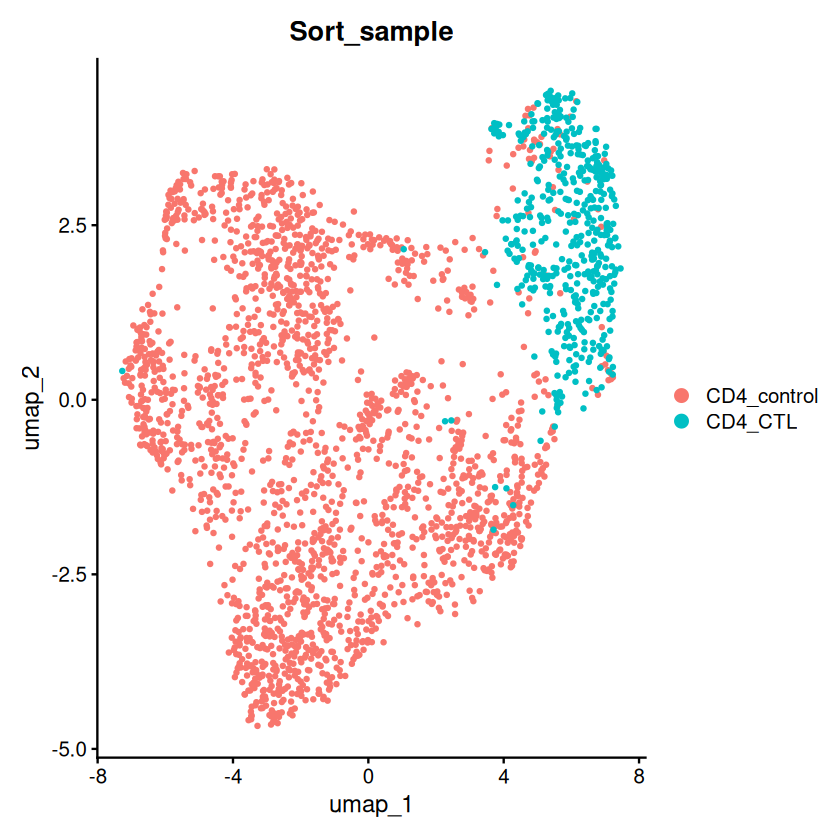

In [9]:
DimPlot(cd4_ctl_sort, group.by = "Sort_sample")

In [12]:
cd4_ctl_sort$Freemuxlet_ID  %>% table

.
    0,0     1,0     1,1     2,2     3,0     3,1     3,3     4,1     4,3     4,4 
    769       1     457     407       2       1     462       1       1     415 
Unknown 
      7 

In [15]:
cd4_ctl_sort@meta.data  <- cd4_ctl_sort@meta.data  %>% mutate(Donor_ID = case_when(
Freemuxlet_ID == "0,0" ~ "Sort_Donor1",
Freemuxlet_ID == "1,1" ~ "Sort_Donor2",
Freemuxlet_ID == "2,2" ~ "Sort_Donor3",
Freemuxlet_ID == "3,3" ~ "Sort_Donor4",
Freemuxlet_ID == "4,4" ~ "Sort_Donor5",
Freemuxlet_ID == "Unknown" ~ "Unknown",
TRUE ~ "Doublet"))

In [16]:
cd4_ctl_sort$Donor_ID  %>% table

.
    Doublet Sort_Donor1 Sort_Donor2 Sort_Donor3 Sort_Donor4 Sort_Donor5 
          6         769         457         407         462         415 
    Unknown 
          7 

In [18]:
cd4_ctl_sort@meta.data  %>% colnames

[1] "orig.ident"         "nCount_RNA"         "nFeature_RNA"      
 [4] "RNA_snn_res.0.9"    "seurat_clusters"    "RNA_snn_res.0.5"   
 [7] "barcode"            "Freemuxlet_ID"      "Freemuxlet_doublet"
[10] "sample"             "Sort_sample"        "Donor_ID"

In [19]:
cd4_ctl_sort$`RNA_snn_res.0.9`  <- NULL
cd4_ctl_sort$`RNA_snn_res.0.5`  <- NULL
cd4_ctl_sort$barcode  <- NULL
cd4_ctl_sort$Freemuxlet_ID  <- NULL
cd4_ctl_sort$Freemuxlet_doublet  <- NULL
cd4_ctl_sort$sample  <- NULL

cd4_ctl_sort@assays$RNA@layers$data  <- NULL
cd4_ctl_sort@assays$RNA@layers$scale.data  <- NULL

In [20]:
cd4_ctl_sort

An object of class Seurat 
19600 features across 2523 samples within 1 assay 
Active assay: RNA (19600 features, 1000 variable features)
 1 layer present: counts
 2 dimensional reductions calculated: pca, umap

In [21]:
dir.create("data/SCP/")

In [23]:
saveRDS(cd4_ctl_sort, "data/SCP/Blood_CD4CTL_sort.rds")

In [30]:
colnames(cd4_ctl_sort@meta.data)

[1] "orig.ident"      "nCount_RNA"      "nFeature_RNA"    "seurat_clusters"
[5] "Sort_sample"     "Donor_ID"